# EEG_13 — DHSLP: Dynamic Hypergraph con Iperedge Apprese

**Salto architetturale rispetto a EEG_09–12**:
Nei notebook precedenti H era costruita da metriche di connettività (PCC, wPLI, ecc.).
Qui le **iperedge sono parametri learnable** aggiornati da backprop — la rete decide
autonomamente quali elettrodi raggruppare, guidata solo dalla loss di classificazione.

```
H_k = softmax(feat_k @ E^T / sqrt(d))   — (B, 61, n_edges)
```
dove `E ∈ R^{n_edges × d}` è una matrice di embedding delle iperedge (parametri della rete).
`feat_k = Linear(x_k) + pos_enc` — feature nodo = signal locale + encoding posizionale elettrodo.

**Ispirazione**: Li et al. 2025 — DHSLP (Dynamic Hypergraph Spectral Learning with Positional encoding).

**Target tesi**: ~78% bAcc (Li et al., loro dataset). Obiettivo realistico: superare ~34% (soffitto EEG_12).

Ablation: n_edges ∈ {16, 32, 64} × d_model ∈ {32, 64} = 6 configurazioni. Split S-Indep.

In [1]:
import json, logging, re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg13')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)

# ---- CONFIG ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

# DHSLP iperparametri
K_WINDOWS    = 8
N_EDGES      = 32
D_MODEL      = 64
HIDDEN       = 128
N_LAYERS     = 2
DROPOUT      = 0.5     # alzato da 0.3

# Training
LR              = 1e-3
WEIGHT_DECAY    = 1e-3  # alzato da 1e-4
GRAD_CLIP       = 1.0
BATCH_SIZE      = 64
MAX_EPOCHS      = 60
PATIENCE        = 12
LABEL_SMOOTHING = 0.1
USE_INSTANCE_NORM = True

# Data augmentation — solo su training set
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

DATA_METRIC = 'abs_pcc'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

T_WIN = N_SAMPLES // K_WINDOWS
log.info(f'K_WINDOWS={K_WINDOWS}  T_WIN={T_WIN}  D_MODEL={D_MODEL}  N_EDGES={N_EDGES}')
log.info(f'TRAIN={len(SUBJ_TRAIN)} VAL={len(SUBJ_VAL)} TEST={len(SUBJ_TEST)}')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  GRAD_CLIP={GRAD_CLIP}  USE_AUG={USE_AUGMENTATION}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
21:55:22 INFO     K_WINDOWS=8  T_WIN=48  D_MODEL=64  N_EDGES=32
21:55:22 INFO     TRAIN=50 VAL=10 TEST=14
21:55:22 INFO     DROPOUT=0.5  WEIGHT_DECAY=0.001  GRAD_CLIP=1.0  USE_AUG=True


## §2 — Dataset (solo x e y — H non necessaria in DHSLP)

In [2]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class EEGRawDataset(Dataset):
    """
    Carica x (61,384) e y dai file .pt — H ignorata (DHSLP la apprende end-to-end).
    """
    def __init__(self, subj_ids, metric=DATA_METRIC, use_instance_norm=True, augment=False):
        root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
        self.paths, self.labels = [], []
        self.use_instance_norm = use_instance_norm
        self.augment = augment
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            if int(m.group(1)) not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is None: continue
            self.paths.append(p)
            self.labels.append(c)
        log.info(f'  {metric} pruned: {len(self.paths)} trial caricati')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)
        return x, torch.tensor(self.labels[idx], dtype=torch.long)


def make_loaders():
    tr = EEGRawDataset(SUBJ_TRAIN, augment=USE_AUGMENTATION)
    va = EEGRawDataset(SUBJ_VAL,   augment=False)
    te = EEGRawDataset(SUBJ_TEST,  augment=False)
    labels   = np.array(tr.labels)
    counts   = np.bincount(labels, minlength=N_CLASSES)
    sample_w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw))

## §3 — Modello: DHSLP

Architettura ispirata a Li et al. 2025.

```
Input x (B, 61, 384)
  → split K=8 finestre temporali → x_k (B, 61, 48)
  per ogni finestra k (shared weights):
    feat_k = Linear(x_k) + pos_enc        → (B, 61, d)  # signal + posizione elettrodo
    H_k    = softmax(feat_k @ E^T / √d)   → (B, 61, n_edges)  # iperedge dinamiche
    out_k  = HGNNConv(feat_k, H_k).mean   → (B, hidden)
z = mean(out_1..K) → Linear → logits (B, 4)
```

`E ∈ R^{n_edges × d}` — parametri delle iperedge (learnable).
`pos_enc ∈ R^{61 × d}` — encoding posizionale per elettrodo (learnable).

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019)."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) — soft, dynamic
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """
    Dynamic Hypergraph Spectral Learning with Positional encoding.
    Ispirato a Li et al. 2025.

    Differenza chiave da W-HGNN (EEG_11/12):
    - H NON è caricata dal disco (nessuna H_pruned)
    - H_k = softmax(feat_k @ E^T / sqrt(d)) — calcolata per ogni trial e finestra
    - E: parametri learnable (n_edges, d_model) — aggiornati da backprop
    - pos_enc: encoding posizionale per elettrodo (61, d_model) — learnable
    """
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model

        # Learnable iperedge embeddings — cuore di DHSLP
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)

        # Encoding posizionale per elettrodo (learnable, uno per canale)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)

        # Proiezione nodo per finestra temporale
        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_model),
            nn.LayerNorm(d_model),
            nn.ELU(),
        )

        # HGNN layers
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        """
        feat: (B, N, d)
        return: H (B, N, n_edges) — matrice incidenza soft per questo batch/finestra
        """
        # Similarità feature nodo ↔ iperedge embedding
        # (B, N, d) @ (d, n_edges) = (B, N, n_edges)
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)   # soft assignment nodo→iperedge

    def forward(self, x):
        # x: (B, N, T) — nessun H in input (calcolata dinamicamente)
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k   = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win)
            feat  = self.node_proj(x_k) + self.pos_enc        # (B,N,d) signal + posizione
            H_k   = self.build_dynamic_H(feat)                # (B,N,n_edges) — dinamica!
            out   = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))   # (B,hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


# Sanity check
_m = DHSLP()
_x = torch.randn(4, N_CHANNELS, N_SAMPLES)
assert _m(_x).shape == (4, N_CLASSES)
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
n_e = sum(p.numel() for name, p in _m.named_parameters() if 'E' == name or 'pos_enc' == name)
log.info(f'DHSLP OK — {n_p:,} param totali  ({n_e} in E+pos_enc)  K={K_WINDOWS} n_edges={N_EDGES} d={D_MODEL}')
del _m, _x


21:55:22 INFO     DHSLP OK — 35,076 param totali  (5952 in E+pos_enc)  K=8 n_edges=32 d=64


## §4 — Train / Eval

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')

_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_dhslp(run_name, model, tr_loader, va_loader, te_loader, config):
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=config, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch(model, tr_loader, opt)
        va_loss, va_b, _, _ = run_epoch(model, va_loader)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b,
                 'train_val_gap': tr_b - va_b,
                 'epoch': epoch})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  early stop epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, te_b, te_lbl, te_pred = run_epoch(model, te_loader)
    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  {run_name}: val={best_val:.4f} test={te_b:.4f}')
    return best_val, te_b, te_lbl, te_pred

21:55:22 INFO     device: cuda


## §5 — Ablation: n_edges × d_model

Ablation su 6 configurazioni:
- `n_edges` ∈ {16, 32, 64} — numero di iperedge learnable
- `d_model` ∈ {32, 64} — dimensione embedding nodo/iperedge

**Perché queste variabili?**
- `n_edges` controlla la granularità delle interazioni di ordine superiore (16=grossolano, 64=fine)
- `d_model` controlla la capacità dell'embedding
- Tutto il resto (K=8, HIDDEN=128, N_LAYERS=2) è uguale a EEG_11/12 per confronto diretto

In [5]:
tr_l, va_l, te_l = make_loaders()
log.info(f'Dataset: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')

ABLATION_CONFIGS = [
    {'n_edges': 16,  'd_model': 32},
    {'n_edges': 16,  'd_model': 64},
    {'n_edges': 32,  'd_model': 32},
    {'n_edges': 32,  'd_model': 64},   # default
    {'n_edges': 64,  'd_model': 32},
    {'n_edges': 64,  'd_model': 64},
]

RESULTS_13 = {}

for cfg_override in ABLATION_CONFIGS:
    ne = cfg_override['n_edges']
    dm = cfg_override['d_model']
    run_name = f'eeg13_DHSLP_E{ne}_d{dm}_{CLUSTER_SCHEME}'
    log.info(f'\n=== {run_name} ===')

    model = DHSLP(n_edges=ne, d_model=dm)
    n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)

    cfg = dict(
        notebook='EEG_13', model='DHSLP', n_classes=N_CLASSES,
        cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, t_win=T_WIN,
        n_edges=ne, d_model=dm,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        weighted_sampler=True,
        dynamic_H='learned_softmax',     # chiave differenza vs EEG_09-12
        topology_source='end_to_end',    # nessuna PCC/PLV pre-calcolata
        n_params=n_p,
        n_train_subj=len(SUBJ_TRAIN),
    )
    val_b, test_b, lbl, pred = train_dhslp(run_name, model, tr_l, va_l, te_l, cfg)
    RESULTS_13[f'E{ne}_d{dm}'] = {'val': val_b, 'test': test_b}

log.info('\n=== ABLATION DONE ===')
for k, v in RESULTS_13.items():
    print(f'  {k:15s}  val={v["val"]:.4f}  test={v["test"]:.4f}')


21:55:42 INFO       abs_pcc pruned: 26123 trial caricati
21:55:47 INFO       abs_pcc pruned: 5500 trial caricati
21:55:54 INFO       abs_pcc pruned: 7260 trial caricati
21:55:54 INFO     Dataset: train=26123 val=5500 test=7260
21:55:54 INFO     
=== eeg13_DHSLP_E16_d32_concr4 ===
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


22:00:38 INFO       early stop epoch 14


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train/bacc,▁▅▅█▄▆▂▄▃▃▄▃▁▃
train/loss,█▅▂▂▂▁▂▁▂▂▁▂▂▂
train_val_gap,▁▄▅█▄▇▅▅▆▄▄▅▄▃
val/bacc,▇█▅▄▆▃▁▅▁▅▇▃▂▅
val/loss,▃▇▁▄▆▅██▇▆▆▆▅▅
epoch,14
test_bacc,0.24161
train/bacc,0.25346
train/loss,1.38631
train_val_gap,-0.00105


22:00:44 INFO       eeg13_DHSLP_E16_d32_concr4: val=0.2593 test=0.2416
22:00:44 INFO     
=== eeg13_DHSLP_E16_d64_concr4 ===


22:06:33 INFO       early stop epoch 17


...

22:30:12 INFO       eeg13_DHSLP_E64_d32_concr4: val=0.2561 test=0.2523
22:30:12 INFO     
=== eeg13_DHSLP_E64_d64_concr4 ===


22:35:00 INFO       early stop epoch 14


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train/bacc,█▇▃█▇▆█▅▅▁▂▁▁▃
train/loss,█▅▄▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,█▂▄▄█▂▃▄▂▁▄▂▃▁
val/bacc,▄█▂▇▃▇▇▄▇▃▁▂▁▄
val/loss,█▂█▁▃█▃▆▇▇▅▅▆▇
epoch,14
test_bacc,0.2494
train/bacc,0.25314
train/loss,1.38609
train_val_gap,-0.00068


22:35:05 INFO       eeg13_DHSLP_E64_d64_concr4: val=0.2593 test=0.2494
22:35:05 INFO     
=== ABLATION DONE ===


  E16_d32          val=0.2593  test=0.2416
  E16_d64          val=0.2553  test=0.2513
  E32_d32          val=0.2551  test=0.2445
  E32_d64          val=0.2604  test=0.2511
  E64_d32          val=0.2561  test=0.2523
  E64_d64          val=0.2593  test=0.2494


## §6 — Risultati + Confronto con EEG_09–12

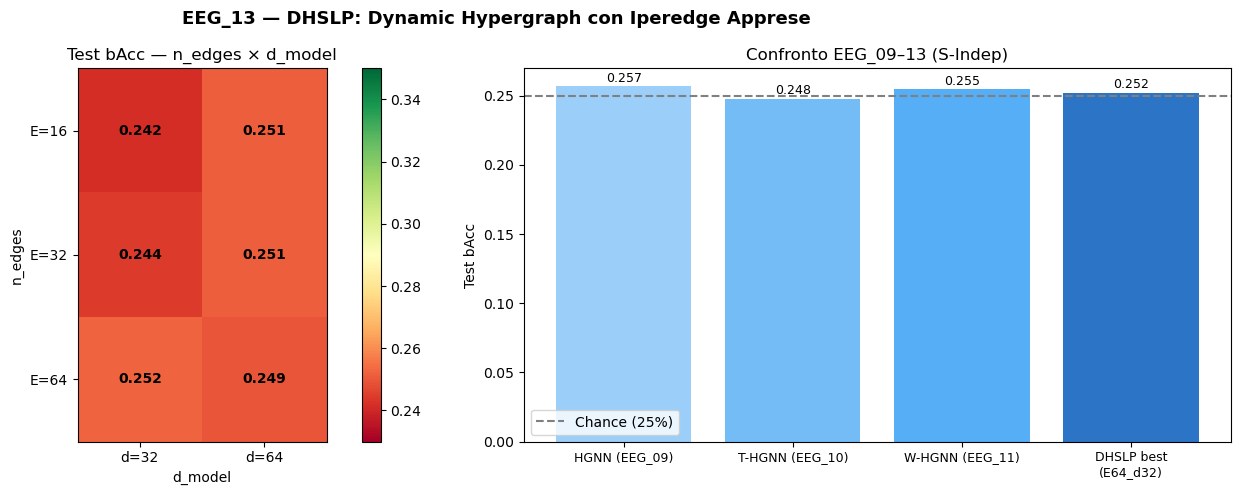


--- Best config ---
  E64_d32: val=0.2561  test=0.2523
  vs HGNN statico (EEG_09): 0.2570  delta=-0.0047
  vs W-HGNN (EEG_11): 0.2550  delta=-0.0027


In [6]:
# Risultati precedenti per confronto
PREV = {
    'HGNN (EEG_09)':   {'test': 0.257},
    'T-HGNN (EEG_10)': {'test': 0.248},
    'W-HGNN (EEG_11)': {'test': 0.255},
}

if RESULTS_13:
    chance = 1 / N_CLASSES
    keys   = list(RESULTS_13.keys())
    vals   = [RESULTS_13[k]['test'] for k in keys]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('EEG_13 — DHSLP: Dynamic Hypergraph con Iperedge Apprese', fontsize=13, fontweight='bold')

    # Ablation heatmap n_edges × d_model
    ax = axes[0]
    n_edges_vals = sorted(set(v['n_edges'] for v in [{'n_edges':16,'d_model':32},{'n_edges':16,'d_model':64},
                                                      {'n_edges':32,'d_model':32},{'n_edges':32,'d_model':64},
                                                      {'n_edges':64,'d_model':32},{'n_edges':64,'d_model':64}]))
    d_model_vals = sorted(set([32, 64]))
    matrix = np.full((len(n_edges_vals), len(d_model_vals)), np.nan)
    for i, ne in enumerate(n_edges_vals):
        for j, dm in enumerate(d_model_vals):
            k = f'E{ne}_d{dm}'
            if k in RESULTS_13:
                matrix[i, j] = RESULTS_13[k]['test']
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.23, vmax=max(0.35, np.nanmax(matrix)+0.02))
    ax.set_xticks(range(len(d_model_vals))); ax.set_xticklabels([f'd={d}' for d in d_model_vals])
    ax.set_yticks(range(len(n_edges_vals))); ax.set_yticklabels([f'E={ne}' for ne in n_edges_vals])
    ax.set_xlabel('d_model'); ax.set_ylabel('n_edges')
    ax.set_title('Test bAcc — n_edges × d_model')
    for i in range(len(n_edges_vals)):
        for j in range(len(d_model_vals)):
            if not np.isnan(matrix[i,j]):
                ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax)
    ax.axhline(-0.5 + 0.5*(matrix > chance).sum(axis=1)[0], color='none')

    # Confronto con precedenti
    ax2 = axes[1]
    best_k  = max(RESULTS_13, key=lambda k: RESULTS_13[k]['test'])
    best_v  = RESULTS_13[best_k]['test']
    bars = {**{k: v['test'] for k, v in PREV.items()}, f'DHSLP best\n({best_k})': best_v}
    colors = ['#90CAF9','#64B5F6','#42A5F5','#1565C0']
    bvals  = list(bars.values())
    blabels= list(bars.keys())
    ax2.bar(range(len(bvals)), bvals, color=colors, alpha=0.9, edgecolor='none')
    ax2.axhline(chance, color='gray', ls='--', lw=1.5, label=f'Chance ({chance:.0%})')
    ax2.set_xticks(range(len(blabels))); ax2.set_xticklabels(blabels, fontsize=9)
    ax2.set_ylabel('Test bAcc'); ax2.set_title('Confronto EEG_09–13 (S-Indep)')
    ax2.legend()
    for i, v in enumerate(bvals):
        ax2.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13_dhslp_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n--- Best config ---')
    print(f'  {best_k}: val={RESULTS_13[best_k]["val"]:.4f}  test={RESULTS_13[best_k]["test"]:.4f}')
    print(f'  vs HGNN statico (EEG_09): {0.257:.4f}  delta={best_v - 0.257:+.4f}')
    print(f'  vs W-HGNN (EEG_11): {0.255:.4f}  delta={best_v - 0.255:+.4f}')
